In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

from flonacomldft.utils.io_utils import (
    load_pickle_file,
    load_csv_file,
    get_path,
)

from flonacomldft.internal_coordinates import Coordinates_mapping
from ase.io.trajectory import Trajectory

In [103]:
import warnings
warnings.filterwarnings('ignore')

# EMT Energy histograms MD

## MD Trajectories

In [104]:
thermostats = ['berendsen', 'andersen']
trajs = [Trajectory(get_path() + '/emt_'+thermostat+'/md_trajectories/is1_emt_'+thermostat+'.traj') for thermostat in thermostats]

In [105]:
us_xyz = np.array([[atoms.get_potential_energy() for atoms in traj] for traj in trajs])

In [106]:
energies_md = {'md '+t: u for t, u in zip(thermostats, us_xyz)}

Text(0.5, 0, 'Energy (eV) (XYZ)')

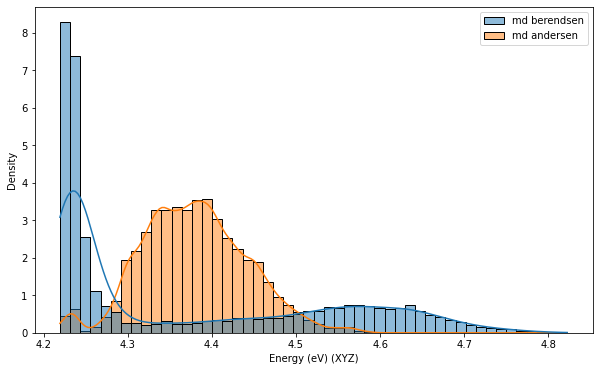

In [107]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.histplot(energies_md, stat='density', bins=50, kde=True, ax=ax)
ax.set_xlabel('Energy (eV) (XYZ)')

## DATASETS

In [108]:
zmats = [load_csv_file('is1_flow_test.csv', get_path()+'/emt_'+thermostat+'/datasets') for thermostat in thermostats]
#zmats = [load_csv_file('is1_emt_'+thermostat+'.csv', get_path()+'/emt_'+thermostat+'/int_coords') for thermostat in thermostats]

In [109]:
coord_mapping = Coordinates_mapping(etype='emt')

In [110]:
xs = []
us_xs = []
for i in range(len(thermostats)):
    x, logdetjac, u = coord_mapping.get_real_centered_from_internal(zmats[i][:, :12], zmats[i][:, 14], isomer=1, energies=zmats[i][:, 12])
    xs.append(x)
    us_xs.append(u)

In [111]:
energies_datasets = {'md dataset '+t: u.detach().numpy() for t, u in zip(thermostats, us_xs)}

Text(0.5, 0, 'Energy (eV) (XS)')

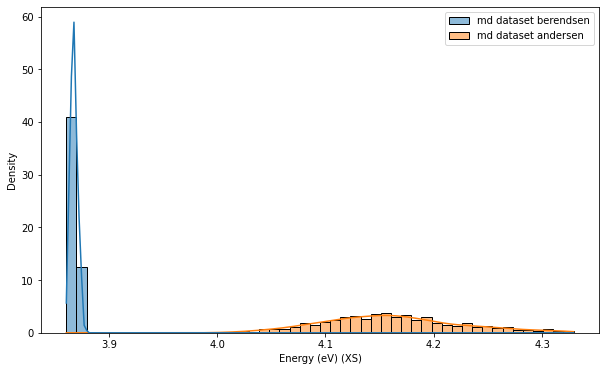

In [112]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.histplot(energies_datasets, stat='density', bins=50, kde=True, ax=ax)
ax.set_xlabel('Energy (eV) (XS)')

In [113]:
pathfile = lambda id_:"/mnt/home/amolina/ceph/EMT/3-adaptive/berendsenVSandersen/results_adaptive_is1_2480473{:d}/".format(id_)
adaptives = [load_pickle_file("adaptive_sampling_is1_2480473{:d}.pkl".format(i), pathfile(i)) for i in range(2)]

In [114]:
us_mcmc = [torch.stack(adaptive['us']).flatten() for adaptive in adaptives][::-1]

In [115]:
energies_mcmc = {'mcmc '+t:u.detach().numpy() for t, u in zip(thermostats, us_mcmc)}

In [116]:
energies = energies_mcmc | energies_datasets

<AxesSubplot:ylabel='Density'>

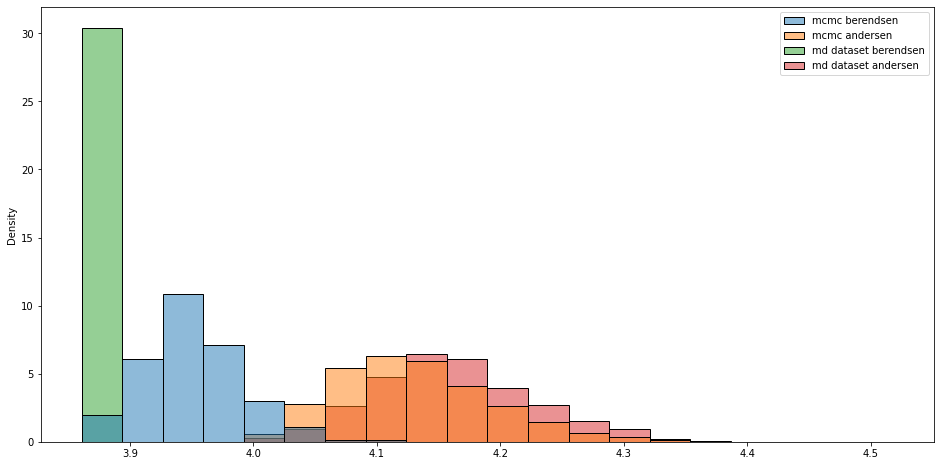

In [119]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8), sharey=True)
sns.histplot(energies, stat='density', bins=20, kde=False, ax=ax, common_norm=False)